
### Project Objectives

The project aims to:

- Estimate the **Average Treatment Effect (ATE)** of the campaign.
- Evaluate treatment assignment and causal assumptions.
- Estimate **Conditional Average Treatment Effects (CATE)**.
- Compare alternative uplift modeling approaches.
- Rank customers by predicted incremental treatment response.
- Evaluate targeting performance using **Decile Analysis and Qini metrics**.
- Develop a practical campaign targeting strategy.

---

### Analytic Framework

```mermaid
flowchart TD

A[Criteo Uplift Data]
B[Data Preparation<br/>Cleaning / Feature Analysis / Train-Test Split]
C[Causal Validation<br/>Randomization / SMD / Propensity / Assumptions]

D1[Overall Treatment Effect<br/>ATE]
D2[Heterogeneous Treatment Effect<br/>CATE]

E1[Difference in Means<br/>RA / IPW / DR]
E2[T-Learner]
E3[X-Learner]

F[Model Evaluation<br/>Qini Comparison]
G[X-Learner Selected]
H[Customer CATE / Uplift Score]
I[Customer Uplift Ranking]
J[Uplift Segmentation<br/>High / Medium / Low / Negative]
K[Policy Evaluation<br/>5% / 10% / 20% / ...]
L[Business Decision<br/>Target ~Top 20%]

A --> B
B --> C
C --> D1
C --> D2

D1 --> E1
D2 --> E2
D2 --> E3

E2 --> F
E3 --> F

F --> G
G --> H
H --> I
I --> J
J --> K
K --> L

# Part A: Causal Inference Analysis

This notebook estimates the causal effect of a marketing campaign on customer conversion by:

- Evaluating treatment assignment and causal assumptions.
- Estimating ATE and CATE using multiple causal estimators.
- Interpreting the results for campaign decision-making.

## 1. Import Libraries

Import the required libraries for data manipulation, visualization, machine learning, and causal inference.

In [51]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np

from evaluation.balance import calculate_covariate_balance

from causal.propensity import fit_propensity_model

from uplift.t_learner import (
    estimate_cate,
    split_uplift_data,
    train_t_learner,
    estimate_t_cate
)

import importlib
import causal.estimators
importlib.reload(causal.estimators)

from causal.estimators import (
    difference_in_means,
    regression_adjustment,
    inverse_probability_weighting,
    doubly_robust,
)

from visualization.Treatment_Analysis import (
    plot_propensity_score_distribution, 
    plot_propensity_score_boxplot, 
    plot_treatment_model_coefficients,
    plot_covariate_balance,
    plot_treatment_distribution,
    plot_standardized_mean_difference)

from visualization.Train_Test_Split import (
    plot_cate_distribution, 
    plot_train_test_treatment_distribution)                                            

from setup import configure_notebook

configure_notebook()

from features.configure import load_configuration

from uplift.x_learner import (
    construct_pseudo_effects,
    train_effect_models,
    estimate_x_cate
)

## 2. Load Configuration

Load project configurations (e.g., dataset paths and variable names) from the `.env` file.

In [52]:
from features.configure import load_configuration

config = load_configuration()

DATASET_PATH = config["dataset_path"]
TARGET = config["target"]
TREATMENT = config["treatment"]

print("Configuration Loaded")
print(f"Dataset Path     : {DATASET_PATH}")
print(f"Target Column    : {TARGET}")
print(f"Treatment Column : {TREATMENT}")

Configuration Loaded
Dataset Path     : /Users/baotram/Desktop/Criteo Uplift/Data/criteo-uplift-v2.1.csv
Target Column    : conversion
Treatment Column : treatment


## 3. Load Dataset

Load the dataset into a Pandas DataFrame for analysis.

In [53]:

df = pd.read_csv(DATASET_PATH)

print("Dataset loaded successfully.")

display(df.head())

Dataset loaded successfully.


,f0,f1,f2,f3,f4,f5,f6,f7,f8,f9,f10,f11,treatment,conversion,visit,exposure
0,12.62,10.06,8.98,4.68,10.28,4.12,0.29,4.83,3.96,13.19,5.30,-0.17,1,0,0,0
1,12.62,10.06,9.00,4.68,10.28,4.12,0.29,4.83,3.96,13.19,5.30,-0.17,1,0,0,0
2,12.62,10.06,8.96,4.68,10.28,4.12,0.29,4.83,3.96,13.19,5.30,-0.17,1,0,0,0
3,12.62,10.06,9.00,4.68,10.28,4.12,0.29,4.83,3.96,13.19,5.30,-0.17,1,0,0,0
4,12.62,10.06,9.04,4.68,10.28,4.12,0.29,4.83,3.96,13.19,5.30,-0.17,1,0,0,0


### Variable Definition

For causal inference, only variables assumed to exist before treatment assignment are used as covariates.

The variables `f0`–`f11` are treated as pre-treatment customer characteristics.

`treatment` is the intervention variable, while `conversion` is the outcome of interest.

`visit` and `exposure` are excluded from the covariate set because they are assumed to occur after treatment and may therefore represent post-treatment variables.

In [54]:
# Pre-treatment covariates
PRE_TREATMENT_FEATURES = [f"f{i}" for i in range(12)]

# Treatment and outcome
TREATMENT = "treatment"
OUTCOME = "conversion"

X = df[PRE_TREATMENT_FEATURES]
T = df[TREATMENT]
Y = df[OUTCOME]

### 2.4 Verify Variable Structure

Before proceeding with the causal analysis, the defined variables are verified to ensure that:

- all selected columns exist in the dataset;
- the feature matrix, treatment variable, and outcome variable contain the same number of observations;
- the treatment and outcome variables are binary;
- there are no missing values in the variables used for the analysis.

This verification helps prevent data preparation errors from affecting subsequent causal inference results.

In [55]:
# Verify variable structure
print("Dataset shape:", df.shape)

print("\nPre-treatment feature matrix shape:", X.shape)
print("Number of pre-treatment features:", X.shape[1])
print("Pre-treatment features:", list(X.columns))

print("\nTreatment distribution:")
print(T.value_counts(dropna=False).sort_index())

print("\nOutcome distribution:")
print(Y.value_counts(dropna=False).sort_index())

print("\nMissing values:")
print("X:", X.isna().sum().sum())
print("T:", T.isna().sum())
print("Y:", Y.isna().sum())

print("\nBinary-variable checks:")
print("Treatment unique values:", sorted(T.dropna().unique()))
print("Outcome unique values:", sorted(Y.dropna().unique()))

print("\nIndex alignment:")
print("X and T aligned:", X.index.equals(T.index))
print("X and Y aligned:", X.index.equals(Y.index))

Dataset shape: (13979592, 16)

Pre-treatment feature matrix shape: (13979592, 12)
Number of pre-treatment features: 12
Pre-treatment features: ['f0', 'f1', 'f2', 'f3', 'f4', 'f5', 'f6', 'f7', 'f8', 'f9', 'f10', 'f11']

Treatment distribution:
treatment
0     2096937
1    11882655
Name: count, dtype: int64

Outcome distribution:
conversion
0    13938818
1       40774
Name: count, dtype: int64

Missing values:
X: 0
T: 0
Y: 0

Binary-variable checks:
Treatment unique values: [np.int64(0), np.int64(1)]
Outcome unique values: [np.int64(0), np.int64(1)]

Index alignment:
X and T aligned: True
X and Y aligned: True


### Inspect the Unique Values of Treatment and Outcome

The treatment (`treatment`) and outcome (`conversion`) variables were examined to verify that they are binary variables suitable for causal inference analysis.

The treatment variable contains two unique values (0 and 1), indicating whether a customer belongs to the control or treatment group.

The outcome variable also contains two unique values (0 and 1), indicating whether a customer converted after the marketing campaign.

In [56]:
# Inspect the unique values of treatment and outcome
binary_variable_check = pd.DataFrame({
    "Variable": [
        TREATMENT,
        OUTCOME
    ],
    "Unique Values": [
        sorted(T.dropna().unique().tolist()),
        sorted(Y.dropna().unique().tolist())
    ],
    "Number of Unique Values": [
        T.nunique(dropna=True),
        Y.nunique(dropna=True)
    ]
})

display(binary_variable_check)

,Variable,Unique Values,Number of Unique Values
0,treatment,"[0, 1]",2
1,conversion,"[0, 1]",2


### Verify That X, T, and Y Contain the Same Number of Observations

The feature matrix (`X`), treatment variable (`T`), and outcome variable (`Y`) were checked to ensure that they contain the same number of observations and are correctly aligned.

This verification confirms that each customer has a corresponding set of pre-treatment covariates, treatment assignment, and observed outcome, ensuring consistency for subsequent causal analysis.

In [57]:
# Verify that X, T, and Y contain the same number of observations
shape_check = pd.DataFrame({
    "Object": [
        "Feature matrix X",
        "Treatment T",
        "Outcome Y"
    ],
    "Shape": [
        str(X.shape),
        str(T.shape),
        str(Y.shape)
    ]
})

display(shape_check)

assert len(X) == len(T) == len(Y), (
    "X, T, and Y do not contain the same number of observations."
)

,Object,Shape
0,Feature matrix X,"(13979592, 12)"
1,Treatment T,"(13979592,)"
2,Outcome Y,"(13979592,)"


The analysis dataset consists of 13,979,592 observations, with 12 pre-treatment features, a treatment indicator, and an outcome variable ready for causal effect estimation.

## 4. Treatment Assignment Analysis

This section evaluates the treatment assignment by:

- Examining the treatment distribution.
- Assessing covariate balance.
- Modelling treatment assignment.
- Evaluating propensity score overlap.

### 4.1 Treatment Distribution

- Summarise the treatment assignment.
- Assess the treatment allocation.

In [58]:
# Number of customers in each treatment group
treatment_count = (
    df[TREATMENT]
    .value_counts()
    .sort_index()
    .rename(index={
        0: "Control",
        1: "Treatment"
    })
)

# Percentage of customers in each treatment group
treatment_percentage = (
    df[TREATMENT]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .rename(index={
        0: "Control",
        1: "Treatment"
    })
)

treatment_distribution = pd.DataFrame({
    "Number of Customers": treatment_count,
    "Percentage (%)": treatment_percentage.round(2)
})

display(treatment_distribution)

,Number of Customers,Percentage (%)
treatment,,
Control,2096937,15.00
Treatment,11882655,85.00


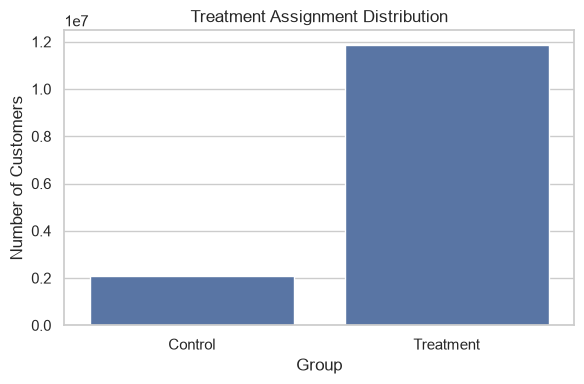

In [59]:
plot_treatment_distribution(
    df=df,
    treatment_col=TREATMENT,
)

The dataset contains substantially more treated than control customers (85% vs. 15%). Although the treatment assignment is imbalanced, this reflects the original experimental design rather than a data quality issue.

### 4.2 Covariate Balance

- Assess covariate balance using the 12 pre-treatment covariates (`f0`–`f11`).
- Exclude the post-treatment variables (`visit` and `exposure`).
- Evaluate balance using the standardized mean difference (SMD).
- Use |SMD| < 0.10 as the balance criterion.

In [60]:
from evaluation.balance import calculate_covariate_balance

balance_table = calculate_covariate_balance(X, T)

display(balance_table)

,Control Mean,Treatment Mean,Control SD,Treatment SD,Pooled SD,SMD,Absolute SMD,Balance Status
f3,4.23,4.17,1.24,1.35,1.30,-0.05,0.05,Balanced
f6,-4.00,-4.18,4.44,4.60,4.52,-0.04,0.04,Balanced
f5,4.04,4.03,0.40,0.44,0.42,-0.03,0.03,Balanced
f9,15.89,16.05,6.80,7.06,6.93,0.02,0.02,Balanced
f1,10.07,10.07,0.09,0.11,0.10,0.02,0.02,Balanced
f8,3.93,3.93,0.06,0.06,0.06,-0.02,0.02,Balanced
f7,5.08,5.11,1.16,1.21,1.19,0.02,0.02,Balanced
f10,5.33,5.33,0.16,0.17,0.17,0.01,0.01,Balanced
f4,10.34,10.34,0.34,0.34,0.34,0.01,0.01,Balanced
f0,19.65,19.61,5.39,5.38,5.38,-0.01,0.01,Balanced


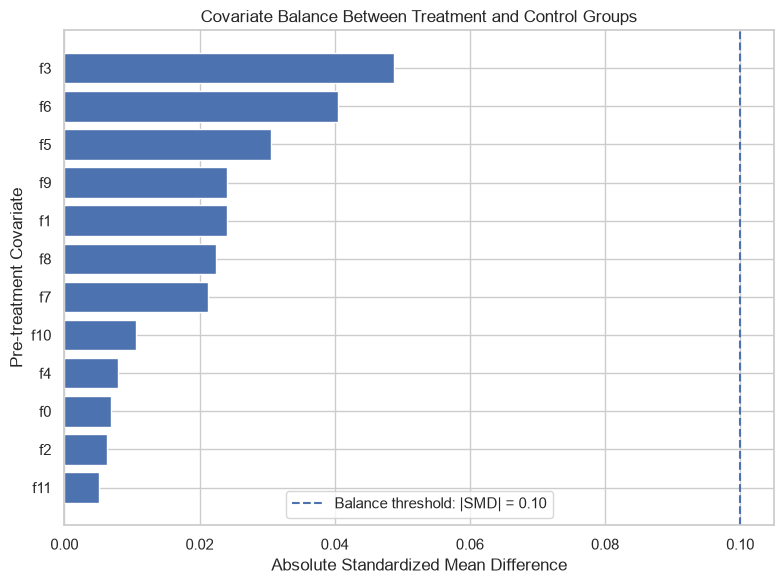

In [61]:
plot_covariate_balance(balance_table)

All pre-treatment covariates satisfy the recommended balance criterion (|SMD| < 0.10), indicating that the treatment and control groups are well balanced with respect to the observed covariates.

### 4.3 Standardized Mean Difference (SMD)

- Quantify covariate differences using the standardized mean difference (SMD).
- Compare balance across covariates on a common scale.
- Use |SMD| < 0.10 as the balance criterion.

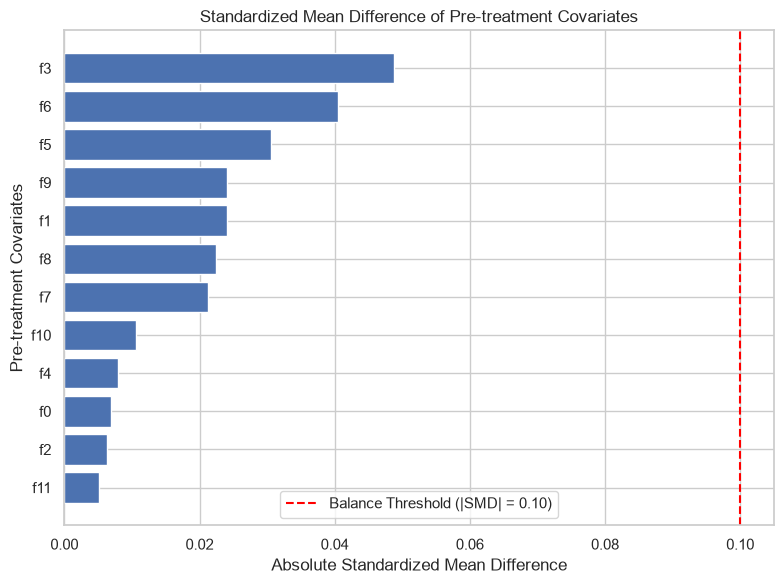

In [62]:
plot_standardized_mean_difference(balance_table)

All covariates satisfy the recommended balance criterion (|SMD| < 0.10), indicating that the treatment and control groups are well balanced on the observed pre-treatment covariates.

### 4.4 Logistic Regression Predicting Treatment

- Fit a logistic regression model using the 12 pre-treatment covariates (`f0`–`f11`).
- Estimate the propensity score for each observation.
- Identify covariates associated with treatment assignment.

In [63]:
propensity_result = fit_propensity_model(
    X=X,
    treatment=T,
)

propensity_model = propensity_result.model
propensity_scores = propensity_result.propensity_scores
coef_table = propensity_result.coefficient_table

df["propensity_score"] = propensity_scores

display(coef_table)

,Feature,Coefficient,Absolute Coefficient
0,f1,0.16,0.16
1,f8,0.06,0.06
2,f10,0.03,0.03
3,f4,-0.03,0.03
4,f3,-0.02,0.02
5,f11,0.01,0.01
6,f7,0.01,0.01
7,f6,-0.00,0.00
8,f2,0.00,0.00
9,f5,-0.00,0.00


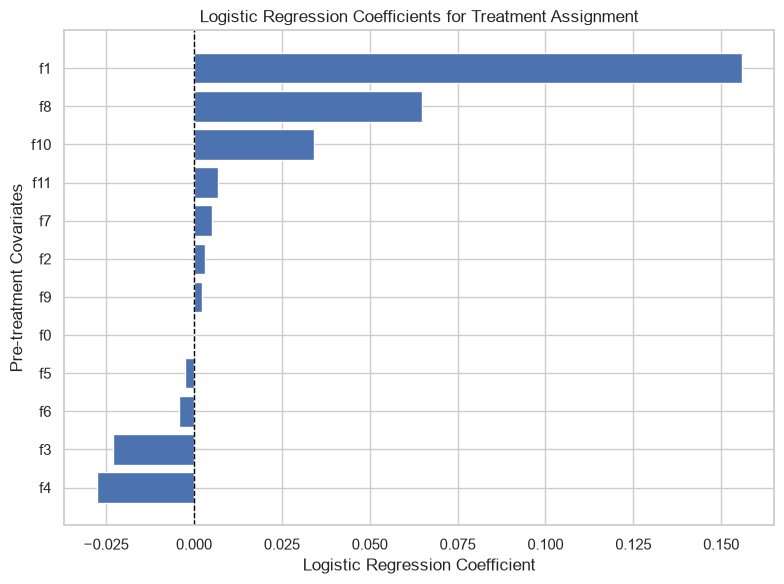

In [64]:

plot_treatment_model_coefficients(coef_table)

Most pre-treatment covariates have coefficients close to zero, with only a few variables showing noticeable associations with treatment assignment. Overall, the observed relationship appears relatively weak.

### 4.5 Propensity Score Distribution

- Examine the propensity score distributions for the treatment and control groups.
- Assess the common support (overlap) assumption.
- Evaluate the comparability of treated and control observations.

In [65]:
propensity_summary = (
    df
    .groupby(TREATMENT)["propensity_score"]
    .describe()
)

propensity_summary

,count,mean,std,min,25%,50%,75%,max
treatment,,,,,,,,
0,2096937.00,0.85,0.01,0.82,0.85,0.85,0.85,0.94
1,11882655.00,0.85,0.01,0.81,0.85,0.85,0.85,0.95


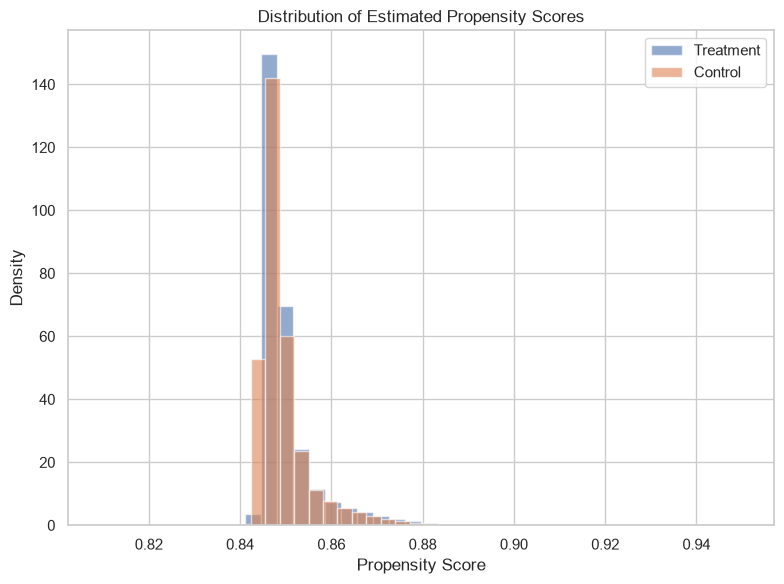

In [66]:

plot_propensity_score_distribution(
    df=df,
    treatment_col=TREATMENT,
    propensity_col="propensity_score"
)

<Figure size 800x600 with 0 Axes>

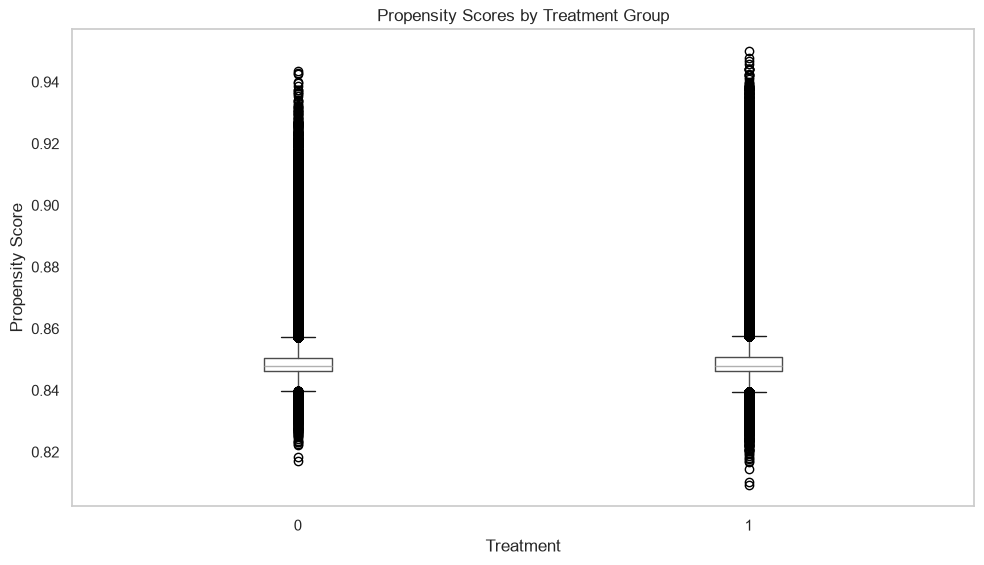

In [67]:
plot_propensity_score_boxplot(
    df=df,
    treatment_col=TREATMENT,
    propensity_col="propensity_score",
)

#### Interpretion
The treatment and control groups show substantial overlap in propensity scores, providing evidence for the positivity assumption and minimal selection bias.


### 4.6 Dataset seems to be randomized?


| Evaluation Question                                     | Evidence                                                                                                                                                                                                                                                                                                                                                                                  | Conclusion                                                                                                             |
| ------------------------------------------------------- | ----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- | ---------------------------------------------------------------------------------------------------------------------- |
| **Does treatment appear randomized?**                   | Although the treatment allocation is imbalanced (85% Treatment vs. 15% Control), all observed pre-treatment covariates are well balanced. The largest absolute Standardized Mean Difference (SMD) is **0.049**, well below the commonly accepted threshold of **0.10**. The estimated propensity score distributions also show substantial overlap between treatment and control groups.  | **Yes. Based on the observed data, the treatment assignment appears approximately randomized.**                        |
| **Can customer features predict treatment assignment?** | Logistic regression coefficients are generally close to zero, with only a few variables (e.g., **f1** and **f8**) showing modest associations. The predicted propensity scores are highly concentrated around **0.85** for both treatment and control groups, indicating that observed customer characteristics provide very limited information for distinguishing treatment assignment. | **Observed customer features have limited predictive power for treatment assignment.**                                 |                                                                                    | **Collectively, these findings support the plausibility of the randomization assumption for the observed covariates.** |


Overall, the observed evidence supports treating the dataset as approximately randomized. Accordingly, the subsequent causal analyses are conducted under the randomized treatment assignment assumption.

# Part B: Causal Inference Framework

- Define the causal question and identification strategy.
- Specify variables for adjustment.
- Establish the assumptions for causal effect estimation.
- Provide the foundation for the subsequent uplift modeling analysis.

## 5.1 Research Question

- Estimate the individual treatment effect (ITE). of the marketing campaign.
- Estimate customer uplift scores.
- Rank customers by expected incremental benefit.
- Support campaign targeting decisions.

## 5.2 Directed Acyclic Graph (DAG)

- Represent the assumed causal relationships.
- Identify the pre-treatment covariates (`f0`–`f11`) as potential confounders.
- Define the treatment and outcome variables.
- Exclude the post-treatment variables (`visit` and `exposure`) from adjustment.

           f0-f11
          /      \
         ▼        ▼
 Treatment ───► Conversion
      │
      ▼
 Visit / Exposure
      │
      ▼
 Conversion

 Adjustment Set:
✓ f0-f11

Excluded:
✗ visit
✗ exposure

**Causal Interpretation**

The DAG identifies the potential sources of confounding before treatment assignment.

The following scenarios illustrate how different treatment assignment mechanisms influence confounding and the choice of causal estimators.

## 5.3 Observable vs Unobservable Confounding

Illustrate how different treatment assignment mechanisms influence confounding and the identification of causal effects.

### Scenario 1

Treatment assignment is randomized.

        Random Assignment
               │
               ▼
 Treatment ───────────▶ Outcome


**Interpretation**

- Treatment assignment is randomized.
- No confounding affects treatment assignment.
- Treatment and control groups are comparable on average.
- Difference in Means consistently estimates the ATE.
- Propensity score adjustment is generally unnecessary.

### Scenario 2

Treatment assignment is observational.

           Confounders
         (Age, History, ...)
          ↙            ↘
 Treatment ───────────▶ Outcome

**Interpretation**

- Treatment assignment is observational.
- Confounders influence both treatment assignment and the outcome.
- Difference in Means may produce a biased ATE estimate.
- Adjustment methods (e.g., propensity score, regression adjustment, IPW, doubly robust estimators) become necessary under the required causal assumptions.

### Conclusion

The Criteo Uplift dataset represents a **randomized treatment assignment**. Therefore, the ATE is directly identifiable, while the following section verifies that the assumptions underlying the randomized experiment are reasonably satisfied.

## 5.4 Identification Strategy

- Identify the pre-treatment covariates (`f0`–`f11`) as the adjustment set.
- Exclude the post-treatment variables (`visit` and `exposure`).
- Use the identified adjustment set for all subsequent causal analyses and uplift models.

### 5.4.1 Consistency

- Verify a well-defined binary treatment (`treatment`) and outcome (`conversion`).
- Confirm that both variables contain no missing values.
- Conclude that the consistency assumption is reasonable.

### 5.4.2 Ignorability (Unconfoundedness)

- Assess the plausibility of the ignorability assumption using the observed covariates.
- Evaluate covariate balance and treatment assignment.
- Acknowledge that unobserved confounding cannot be ruled out.

### 5.4.3 Positivity (Overlap)

- Assess the positivity assumption using the propensity score distributions.
- Evaluate the overlap between the treatment and control groups.
- Conclude that the overlap assumption is reasonably supported.

# Part C: Uplift Modeling

- Select an appropriate uplift modeling approach.
- Train the uplift model.
- Estimate the individual treatment effect (ITE).
- Support customer targeting decisions.

## 6.1 Model Selection

Two meta-learners are evaluated for uplift modeling:

- **T-Learner** is used as a baseline model by estimating separate outcome models for the treatment and control groups.
- **X-Learner** extends these outcome models by learning treatment effects from imputed counterfactual outcomes.
- Both models are evaluated on the same test set.
- The final model is selected based on uplift ranking performance using the Qini curve and Qini coefficient.

## 6.2 Train-Test Split

- Split the dataset into training and testing sets.
- Train the uplift model on the training set.
- Evaluate the model on the testing set.
- Preserve the original treatment allocation using stratified sampling.

In [68]:
split_data = split_uplift_data(
    X=X,
    treatment=T,
    outcome=Y,
    test_size=0.20,
    random_state=42,
)

X_train = split_data.X_train
X_test = split_data.X_test

T_train = split_data.T_train
T_test = split_data.T_test

Y_train = split_data.Y_train
Y_test = split_data.Y_test

In [69]:
print("Training Set")
print("Features :", X_train.shape)
print("Treatment:", T_train.shape)
print("Outcome  :", Y_train.shape)

print()

print("Testing Set")
print("Features :", X_test.shape)
print("Treatment:", T_test.shape)
print("Outcome  :", Y_test.shape)

Training Set
Features : (11183673, 12)
Treatment: (11183673,)
Outcome  : (11183673,)

Testing Set
Features : (2795919, 12)
Treatment: (2795919,)
Outcome  : (2795919,)


In [70]:
train_ratio = (
    T_train
    .value_counts(normalize=True)
    .rename("Train")
)

test_ratio = (
    T_test
    .value_counts(normalize=True)
    .rename("Test")
)

pd.concat([train_ratio, test_ratio], axis=1)

,Train,Test
treatment,,
1,0.85,0.85
0,0.15,0.15


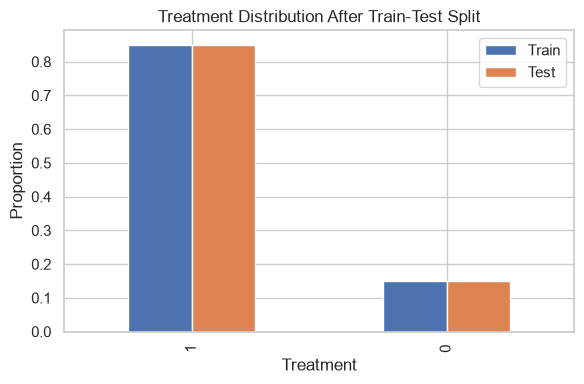

In [71]:
plot_train_test_treatment_distribution(
    train_ratio=train_ratio,
    test_ratio=test_ratio,
)

The treatment proportions remain unchanged after the train-test split, indicating that the split preserved the original data distribution. This supports reliable model training and evaluation.

## 6.3 Training the T-Learner

- Train separate outcome models for the treatment and control groups.
- Learn the relationship between the pre-treatment covariates (`f0`–`f11`) and conversion.
- Predict the probability of conversion under both treatment conditions.

In [72]:
t_learner_result = train_t_learner(
    X_train=X_train,
    treatment_train=T_train,
    outcome_train=Y_train,
)

treatment_model = t_learner_result.treatment_model
control_model = t_learner_result.control_model

In [73]:
print("Treatment Group")
print(
    "Training observations:",
    f"{t_learner_result.treatment_sample_size:,}",
)
print(
    "Training time:",
    f"{t_learner_result.treatment_training_time:.2f} seconds",
)

print()

print("Control Group")
print(
    "Training observations:",
    f"{t_learner_result.control_sample_size:,}",
)
print(
    "Training time:",
    f"{t_learner_result.control_training_time:.2f} seconds",
)

Treatment Group
Training observations: 9,506,123
Training time: 9.33 seconds

Control Group
Training observations: 1,677,550
Training time: 3.27 seconds


### Findings

- The treatment group contains substantially more observations than the control group (9.51M vs 1.68M).
- As a result, the treatment outcome model is trained on much more data than the control outcome model.
- This imbalance may lead to different estimation precision between the two T-Learner outcome models.
- The imbalance also motivates evaluating the X-Learner, which is designed to better handle unequal treatment and control sample sizes.

## 6.4 Training the X-Learner
Train separate outcome models for the treatment and control groups.
Estimate the missing potential outcome for each observation.
Construct pseudo treatment effects for both groups.
Train separate treatment-effect models using the pseudo effects.
Combine the two treatment-effect estimates to obtain the final CATE.

### 6.4.1 Prepare X-Learner Training Groups

The X-Learner reuses the treatment and control outcome models previously trained by the T-Learner.

The training data are separated into treated and control observations to construct the pseudo treatment effects required by the X-Learner.

In [74]:
# The X-Learner reuses the outcome models trained by the T-Learner

treatment_model_x = treatment_model
control_model_x = control_model

print("Outcome models successfully reused.")

treated_mask = T_train == 1
control_mask = T_train == 0

X_train_treated = X_train.loc[treated_mask]
Y_train_treated = Y_train.loc[treated_mask]

X_train_control = X_train.loc[control_mask]
Y_train_control = Y_train.loc[control_mask]

Outcome models successfully reused.


### 6.4.2 Construct Pseudo Treatment Effects
Predict the missing control outcome for treated customers.
Predict the missing treatment outcome for control customers.
Construct pseudo treatment effects for both groups.
Use the pseudo effects as targets for the treatment-effect models.

In [75]:
D1, D0 = construct_pseudo_effects (
    treatment_model=treatment_model,
    control_model=control_model,
    X_treated=X_train_treated,
    y_treated=Y_train_treated,
    X_control=X_train_control,
    y_control=Y_train_control,
)

print(f"Mean D1: {D1.mean():.6f}")
print(f"Mean D0: {D0.mean():.6f}")

Mean D1: 0.000882
Mean D0: 0.000927


### 6.4.3 Train Treatment-Effect Models
Train one model to learn the pseudo effects among treated customers.
Train one model to learn the pseudo effects among control customers.
Model the relationship between customer characteristics and treatment effects.
Use regression models because the pseudo effects are continuous values.

In [76]:
tau_model_treated, tau_model_control = train_effect_models(
    X_treated=X_train_treated,
    D1=D1,
    X_control=X_train_control,
    D0=D0,
)

print("Treatment-effect models trained successfully.")

Treatment-effect models trained successfully.


### 6.4.4 Estimate X-Learner CATE
For each observation, the X-Learner produces two treatment-effect estimates: one learned from the treated group and one learned from the control group.

Predict the treatment effect using both effect models.
Use the propensity score to determine how much weight to assign to each estimate.
Combine the two estimates to obtain the final CATE. 

In [77]:
(
    estimated_cate_x,
    tau_treated_pred,
    tau_control_pred,
    propensity_test,
) = estimate_x_cate(
    tau_model_treated=tau_model_treated,
    tau_model_control=tau_model_control,
    propensity_model=propensity_model,
    X=X_test,
)

print("X-Learner CATE successfully estimated.")

X-Learner CATE successfully estimated.


In [78]:
x_learner_results = pd.DataFrame({
    "treatment": T_test.to_numpy(),
    "outcome": Y_test.to_numpy(),
    "tau_treated": tau_treated_pred,
    "tau_control": tau_control_pred,
    "propensity_score": propensity_test,
    "estimated_cate": estimated_cate_x,
})

display(x_learner_results.head())



,treatment,outcome,tau_treated,tau_control,propensity_score,estimated_cate
0,0,0,0.00,0.00,0.85,0.00
1,1,0,0.00,0.00,0.86,0.00
2,0,0,0.00,0.00,0.85,0.00
3,1,0,0.00,0.00,0.87,0.00
4,1,0,0.00,0.00,0.85,0.00


In [79]:
pd.set_option("display.float_format", "{:.6f}".format)

print("tau_treated:")
print(pd.Series(tau_treated_pred).describe())

print("\ntau_control:")
print(pd.Series(tau_control_pred).describe())

print("\nFinal X-Learner CATE:")
print(pd.Series(estimated_cate_x).describe())

print("Final X-Learner CATE:")
print(pd.Series(estimated_cate_x).describe(
    percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]
))

tau_treated:
count   2795919.000000
mean          0.000857
std           0.009306
min          -0.715245
25%           0.000021
50%           0.000021
75%           0.000075
max           0.738849
dtype: float64

tau_control:
count   2795919.000000
mean          0.001023
std           0.010544
min          -0.710786
25%           0.000106
50%           0.000129
75%           0.000286
max           0.958137
dtype: float64

Final X-Learner CATE:
count   2795919.000000
mean          0.000999
std           0.009555
min          -0.651929
25%           0.000093
50%           0.000112
75%           0.000245
max           0.881323
dtype: float64
Final X-Learner CATE:
count   2795919.000000
mean          0.000999
std           0.009555
min          -0.651929
1%            0.000093
5%            0.000093
25%           0.000093
50%           0.000112
75%           0.000245
95%           0.002441
99%           0.015744
max           0.881323
dtype: float64


### 6.4.5 Inspect CATE Distribution

The distribution of the estimated CATE is examined to understand how treatment effects vary across observations.

Positive CATE indicates that the treatment is expected to increase the outcome.
Negative CATE indicates that the treatment may have an adverse effect.
The variation in CATE provides the basis for ranking observations by their expected treatment response.

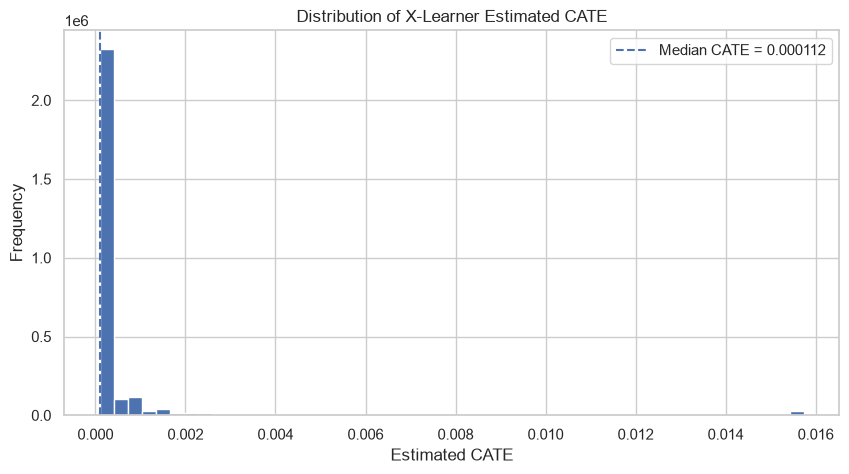

In [80]:
cate_series = pd.Series(estimated_cate_x)

# Focus visualization on the central 98% of predictions
lower = cate_series.quantile(0.01)
upper = cate_series.quantile(0.99)

plt.figure(figsize=(10, 5))

plt.hist(
    cate_series.clip(lower, upper),
    bins=50
)

plt.axvline(
    cate_series.median(),
    linestyle="--",
    label=f"Median CATE = {cate_series.median():.6f}"
)

plt.xlabel("Estimated CATE")
plt.ylabel("Frequency")
plt.title("Distribution of X-Learner Estimated CATE")
plt.legend()

plt.show()

#### Findings

* The estimated CATE distribution is strongly right-skewed, with most observations having treatment effects close to zero.
* A small group of observations shows substantially higher predicted uplift, indicating heterogeneous treatment responses.
* This variation allows customers to be ranked by their expected incremental response to treatment.


### 6.4.6 CATE Ranking and Decile Analysis

To evaluate whether the X-Learner identifies customers who respond differently to treatment:

* Rank observations from highest to lowest predicted CATE.
* Divide the ranked observations into 10 equally sized groups (deciles).
* For each decile, compare the observed outcome rate between treated and control observations.
* Higher-ranked deciles are expected to show larger observed uplift if the model ranks treatment effects effectively.


In [81]:
# Rank observations by predicted CATE
decile_results = x_learner_results.copy()

decile_results["decile"] = pd.qcut(
    decile_results["estimated_cate"].rank(
        method="first",
        ascending=False
    ),
    q=10,
    labels=range(1, 11)
)

# Calculate observed outcome rates by treatment group within each decile
decile_summary = (
    decile_results
    .groupby(["decile", "treatment"], observed=True)["outcome"]
    .mean()
    .unstack()
)

decile_summary.columns = ["control_rate", "treatment_rate"]

# Observed uplift = treated outcome rate - control outcome rate
decile_summary["observed_uplift"] = (
    decile_summary["treatment_rate"]
    - decile_summary["control_rate"]
)

# Add average predicted CATE for comparison
predicted_cate_by_decile = (
    decile_results
    .groupby("decile", observed=True)["estimated_cate"]
    .mean()
)

decile_summary["mean_predicted_cate"] = predicted_cate_by_decile

display(decile_summary)

,control_rate,treatment_rate,observed_uplift,mean_predicted_cate
decile,,,,
1,0.015395,0.024014,0.008620,0.009034
2,0.001533,0.002346,0.000813,0.000564
3,0.000543,0.000628,0.000085,0.000246
4,0.000281,0.000443,0.000162,0.000156
5,0.000070,0.000237,0.000167,0.000113
6,0.000188,0.000232,0.000044,0.000103
7,0.000000,0.000088,0.000088,0.000093
8,0.000000,0.000101,0.000101,0.000093
9,0.000047,0.000051,0.000003,0.000093


The decile results are formally evaluated in Part D.

### 6.4.7 Qini Curve Evaluation

The Qini curve evaluates whether the model ranks customers according to their incremental response to treatment.

* Customers are ranked from highest to lowest predicted CATE.
* The curve measures the cumulative incremental outcome as more customers are targeted.
* A model whose Qini curve lies above the random-targeting baseline provides useful uplift ranking.


In [82]:
# Sort customers from highest to lowest predicted uplift
qini_data = (
    x_learner_results
    .sort_values("estimated_cate", ascending=False)
    .reset_index(drop=True)
)

# Cumulative treated/control observations
qini_data["cum_treated"] = qini_data["treatment"].cumsum()
qini_data["cum_control"] = (1 - qini_data["treatment"]).cumsum()

# Cumulative positive outcomes
qini_data["cum_y_treated"] = (
    qini_data["outcome"] * qini_data["treatment"]
).cumsum()

qini_data["cum_y_control"] = (
    qini_data["outcome"] * (1 - qini_data["treatment"])
).cumsum()

# Cumulative incremental gain
qini_data["qini_gain"] = (
    qini_data["cum_y_treated"]
    - qini_data["cum_y_control"]
    * qini_data["cum_treated"]
    / qini_data["cum_control"].replace(0, np.nan)
)

# Fraction of population targeted
qini_data["population_fraction"] = (
    np.arange(1, len(qini_data) + 1) / len(qini_data)
)

# Random-targeting baseline
final_gain = qini_data["qini_gain"].iloc[-1]

qini_data["random_gain"] = (
    qini_data["population_fraction"] * final_gain
)

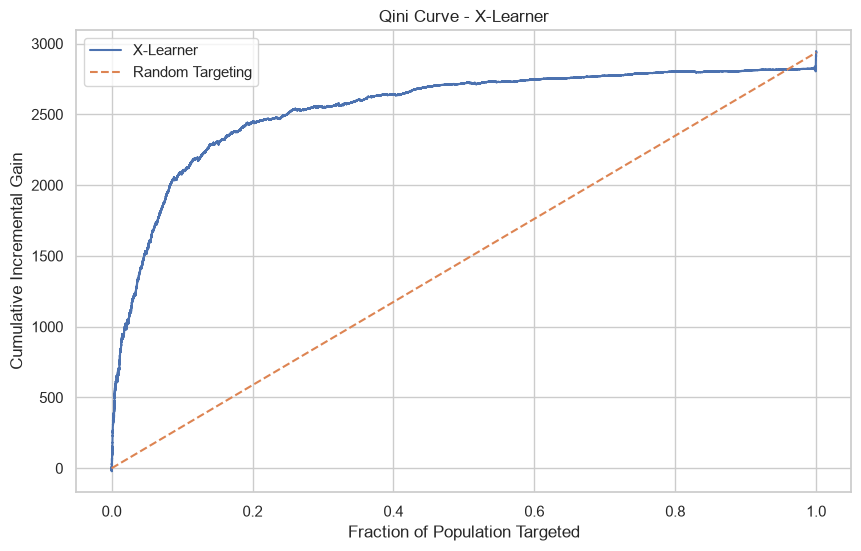

In [83]:
plt.figure(figsize=(10, 6))

plt.plot(
    qini_data["population_fraction"],
    qini_data["qini_gain"],
    label="X-Learner"
)

plt.plot(
    qini_data["population_fraction"],
    qini_data["random_gain"],
    linestyle="--",
    label="Random Targeting"
)

plt.xlabel("Fraction of Population Targeted")
plt.ylabel("Cumulative Incremental Gain")
plt.title("Qini Curve - X-Learner")
plt.legend()

plt.show()

The Qini performance is formally evaluated in Part D.

### 6.4.8 AUUC Evaluation

The Area Under the Uplift Curve (AUUC) summarizes the overall ranking performance of the uplift model.

Unlike the Qini coefficient, which measures improvement over random targeting, AUUC evaluates the total cumulative uplift captured across the entire ranked customer population.

A larger AUUC indicates better overall uplift ranking performance.

In [84]:
# Remove rows where cumulative gain is undefined
auuc_valid = qini_data.dropna(
    subset=["qini_gain", "population_fraction"]
)

# Area Under the Uplift Curve
auuc_x = np.trapezoid(
    auuc_valid["qini_gain"],
    auuc_valid["population_fraction"]
)

print(f"X-Learner AUUC: {auuc_x:.2f}")

X-Learner AUUC: 2542.30


The AUUC Evaluation performance is formally evaluated in Part D.

### 6.4.9 Qini Coefficient

The Qini coefficient summarizes the model's uplift ranking performance into a single value.

* It measures the area between the model's Qini curve and the random-targeting baseline.
* A larger positive Qini coefficient indicates better uplift ranking.
* The coefficient can be used to compare the performance of different uplift models.


In [85]:
qini_valid = qini_data.dropna(
    subset=["qini_gain", "random_gain"]
)

area_model = np.trapezoid(
    qini_valid["qini_gain"],
    qini_valid["population_fraction"]
)

area_random = np.trapezoid(
    qini_valid["random_gain"],
    qini_valid["population_fraction"]
)

qini_coefficient_x = area_model - area_random

print(f"X-Learner Qini Coefficient: {qini_coefficient_x:.2f}")

X-Learner Qini Coefficient: 1073.98


The Qini Coefficient performance is formally evaluated in Part D.

### 6.5 T-Learner vs X-Learner Comparison

To compare the two uplift models fairly:

* Estimate T-Learner CATE on the same test set.
* Rank customers by predicted CATE for each model.
* Calculate Qini performance using the same evaluation method.
* Compare the Qini curves and coefficients to determine which model provides better uplift ranking.


### 6.5.1 T-Learner CATE 

In [86]:
estimated_cate_t, mu1_test, mu0_test = estimate_t_cate(
    treatment_model=treatment_model,
    control_model=control_model,
    X=X_test,
)

t_learner_results = pd.DataFrame({
    "treatment": T_test.to_numpy(),
    "outcome": Y_test.to_numpy(),
    "estimated_cate": estimated_cate_t,
})

print("T-Learner CATE successfully estimated.")

T-Learner CATE successfully estimated.


The T-Learner CATE is formally evaluated in Part D.

### 6.5.2 Calculate T-Learner Qini

In [87]:
# Sort customers from highest to lowest predicted uplift
qini_t = (
    t_learner_results
    .sort_values("estimated_cate", ascending=False)
    .reset_index(drop=True)
)

# Cumulative treated/control observations
qini_t["cum_treated"] = qini_t["treatment"].cumsum()
qini_t["cum_control"] = (1 - qini_t["treatment"]).cumsum()

# Cumulative positive outcomes
qini_t["cum_y_treated"] = (
    qini_t["outcome"] * qini_t["treatment"]
).cumsum()

qini_t["cum_y_control"] = (
    qini_t["outcome"] * (1 - qini_t["treatment"])
).cumsum()

# Cumulative incremental gain
qini_t["qini_gain"] = (
    qini_t["cum_y_treated"]
    - qini_t["cum_y_control"]
    * qini_t["cum_treated"]
    / qini_t["cum_control"].replace(0, np.nan)
)

# Fraction of population targeted
qini_t["population_fraction"] = (
    np.arange(1, len(qini_t) + 1) / len(qini_t)
)

# Random-targeting baseline
final_gain_t = qini_t["qini_gain"].iloc[-1]

qini_t["random_gain"] = (
    qini_t["population_fraction"] * final_gain_t
)

# Calculate Qini coefficient
qini_t_valid = qini_t.dropna(
    subset=["qini_gain", "random_gain"]
)

area_t = np.trapezoid(
    qini_t_valid["qini_gain"],
    qini_t_valid["population_fraction"]
)

area_random_t = np.trapezoid(
    qini_t_valid["random_gain"],
    qini_t_valid["population_fraction"]
)

qini_coefficient_t = area_t - area_random_t

print(f"T-Learner Qini Coefficient: {qini_coefficient_t:.2f}")
print(f"X-Learner Qini Coefficient: {qini_coefficient_x:.2f}")

T-Learner Qini Coefficient: 624.21
X-Learner Qini Coefficient: 1073.98


The T-Learner Qini Coefficient and X-Learner Qini Coefficient is formally evaluated in Part D.

### 6.5.3 Compare Qini Curves

The T-Learner and X-Learner are compared using the same test population and Qini evaluation method.

A model with a higher Qini curve identifies high-uplift customers earlier in the ranking, resulting in greater cumulative incremental gain.

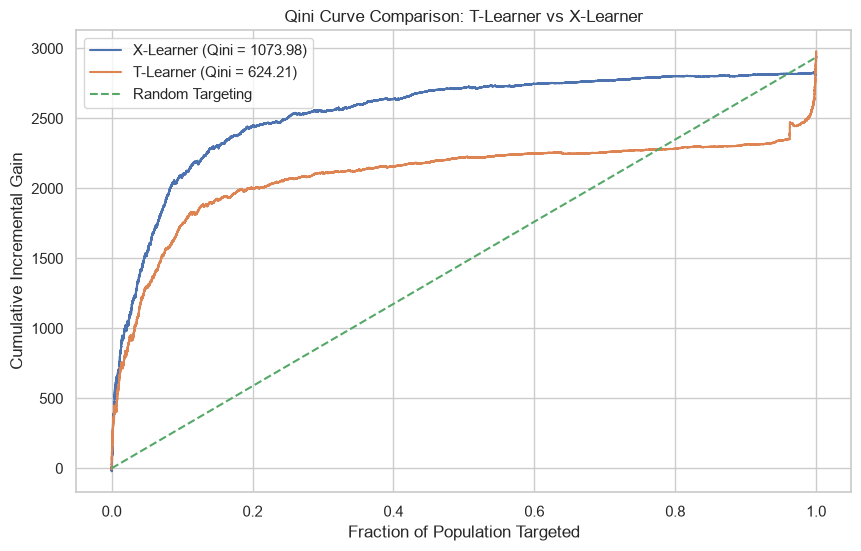

In [88]:
plt.figure(figsize=(10, 6))

# X-Learner
plt.plot(
    qini_data["population_fraction"],
    qini_data["qini_gain"],
    label=f"X-Learner (Qini = {qini_coefficient_x:.2f})"
)

# T-Learner
plt.plot(
    qini_t["population_fraction"],
    qini_t["qini_gain"],
    label=f"T-Learner (Qini = {qini_coefficient_t:.2f})"
)

# Random targeting baseline
plt.plot(
    qini_data["population_fraction"],
    qini_data["random_gain"],
    linestyle="--",
    label="Random Targeting"
)

plt.xlabel("Fraction of Population Targeted")
plt.ylabel("Cumulative Incremental Gain")
plt.title("Qini Curve Comparison: T-Learner vs X-Learner")
plt.legend()

plt.show()

Comparison of Qini Curves is formally evaluated in Part D.

### 7. Customer Targeting Strategy

### 7.1 Model Selection

Based on the Qini comparison, the X-Learner is selected as the final model for customer ranking and campaign targeting.

## 7.2 Customer Uplift Score

- Use the X-Learner estimated CATE as the final customer uplift score.
- Rank customers from highest to lowest expected incremental treatment effect.
- Customers with higher uplift scores are expected to benefit more from the campaign and should receive higher targeting priority.

In [89]:
# Use X-Learner CATE as the final uplift score
customer_ranking = x_learner_results.copy()

customer_ranking["uplift_score"] = customer_ranking["estimated_cate"]

# Rank customers from highest to lowest uplift
customer_ranking = customer_ranking.sort_values(
    "uplift_score",
    ascending=False
).reset_index(drop=True)

customer_ranking["rank"] = (
    np.arange(1, len(customer_ranking) + 1)
)

display(
    customer_ranking[
        [
            "rank",
            "treatment",
            "outcome",
            "uplift_score"
        ]
    ]
    .head(20)
    .style.format({
        "uplift_score": "{:.6f}"
    })
)

,rank,treatment,outcome,uplift_score
0,1,0,0,0.881323
1,2,1,1,0.763399
2,3,1,0,0.757502
3,4,1,0,0.737140
4,5,0,1,0.727304
5,6,1,0,0.725400
6,7,0,0,0.697076
7,8,1,1,0.691151
8,9,1,1,0.682562
9,10,1,0,0.674695


### 7.3 Uplift Segmentation

Customers are segmented based on their predicted X-Learner uplift score.

* High uplift: customers with the strongest predicted incremental treatment effect.
* Medium uplift: customers with moderate expected treatment benefit.
* Low uplift: customers with small positive treatment effect.
* Negative uplift: customers predicted to respond adversely to treatment.


In [90]:
# Define uplift segments based on the X-Learner ranking

customer_ranking["uplift_segment"] = "Low Uplift"

# Negative uplift
customer_ranking.loc[
    customer_ranking["uplift_score"] < 0,
    "uplift_segment"
] = "Negative Uplift"

# Among positive-uplift customers, use percentile thresholds
positive_scores = customer_ranking.loc[
    customer_ranking["uplift_score"] >= 0,
    "uplift_score"
]

high_threshold = positive_scores.quantile(0.90)
medium_threshold = positive_scores.quantile(0.50)

customer_ranking.loc[
    customer_ranking["uplift_score"] >= high_threshold,
    "uplift_segment"
] = "High Uplift"

customer_ranking.loc[
    (customer_ranking["uplift_score"] >= medium_threshold)
    & (customer_ranking["uplift_score"] < high_threshold),
    "uplift_segment"
] = "Medium Uplift"

# Summary
segment_summary = (
    customer_ranking
    .groupby("uplift_segment")["uplift_score"]
    .agg(["count", "mean", "min", "max"])
    .sort_values("mean", ascending=False)
)

display(segment_summary)

,count,mean,min,max
uplift_segment,,,,
High Uplift,278688,0.009060,0.000882,0.881323
Medium Uplift,1114748,0.000271,0.000112,0.000882
Low Uplift,1393436,0.000095,0.000000,0.000112
Negative Uplift,9047,-0.018411,-0.651929,-0.000000


#### Findings

* Most customers have positive but relatively small predicted treatment effects.
* The High Uplift segment shows substantially larger predicted uplift than the Medium and Low Uplift segments.
* A small number of customers have negative predicted uplift, indicating that treatment may be ineffective or potentially adverse for these customers.
* These segments provide a basis for prioritizing customers in the campaign targeting strategy.


### 7.4 Campaign Targeting Strategy

To determine an appropriate campaign targeting range:

* Customers are targeted from highest to lowest X-Learner uplift score.
* Campaign performance is evaluated at different population cutoffs.
* Cumulative incremental gain measures the total additional outcome generated by targeting each group.
* Incremental gain per targeted customer is used to assess targeting efficiency.


In [91]:
# Population cutoffs to evaluate
cutoffs = [0.05, 0.10, 0.20, 0.30, 0.40, 0.50, 0.75, 1.00]

targeting_results = []

n = len(qini_data)

for cutoff in cutoffs:
    idx = min(int(n * cutoff) - 1, n - 1)

    customers_targeted = idx + 1
    cumulative_gain = qini_data.loc[idx, "qini_gain"]

    gain_per_customer = (
        cumulative_gain / customers_targeted
    )

    targeting_results.append({
        "population_targeted": cutoff,
        "customers_targeted": customers_targeted,
        "cumulative_gain": cumulative_gain,
        "gain_per_customer": gain_per_customer
    })

targeting_summary = pd.DataFrame(targeting_results)

display(
    targeting_summary.style.format({
        "population_targeted": "{:.0%}",
        "cumulative_gain": "{:.2f}",
        "gain_per_customer": "{:.6f}"
    })
)

,population_targeted,customers_targeted,cumulative_gain,gain_per_customer
0,5%,139795,1527.00,0.010923
1,10%,279591,2080.78,0.007442
2,20%,559183,2446.81,0.004376
3,30%,838775,2549.77,0.003040
4,40%,1118367,2638.12,0.002359
5,50%,1397959,2718.23,0.001944
6,75%,2096939,2787.01,0.001329
7,100%,2795919,2936.66,0.001050


The targeting strategy is evaluated in Part D using cumulative gain capture and targeting efficiency.

# Part D: Evaluation

This part evaluates the proposed uplift modeling framework from three perspectives:

* **Causal effect:** whether the treatment generates a positive average effect on customer conversion.
* **Uplift model performance:** whether the selected model effectively ranks customers by incremental treatment response.
* **Campaign targeting performance:** whether model-based targeting can concentrate incremental gains among a smaller group of customers.


## 8. Overall Treatment Effect

Before evaluating customer-level uplift, the overall treatment effect is estimated using the difference in mean outcome between the treatment and control groups.

- Treatment mean represents the observed response rate among treated customers.
- Control mean represents the observed response rate without treatment.
- Their difference provides an estimate of the Average Treatment Effect (ATE).

A positive ATE indicates that the treatment increases the outcome on average across the population.

In [92]:
# Calculate observed outcome rates
treatment_mean = Y_test[T_test == 1].mean()
control_mean = Y_test[T_test == 0].mean()

# Difference in means (ATE)
ate = treatment_mean - control_mean

print(f"Treatment Mean : {treatment_mean:.6f}")
print(f"Control Mean   : {control_mean:.6f}")
print(f"ATE            : {ate:.6f}")
print(f"ATE (pp)       : {ate * 100:.4f} percentage points")

Treatment Mean : 0.003136
Control Mean   : 0.001900
ATE            : 0.001236
ATE (pp)       : 0.1236 percentage points


### Findings

- The treatment group achieved a conversion rate of 0.3136%, compared with 0.1900% for the control group.
- The estimated ATE is positive at 0.001236, equivalent to an increase of 0.1236 percentage points.
- This indicates that the treatment improves conversion on average across the test population.
- However, the ATE only measures the average effect and does not show whether the treatment effect differs across customers.

## 9. Heterogeneous Treatment Effect Evaluation

The positive ATE shows that the treatment is effective on average, but the effect may not be the same for every customer.

The X-Learner estimated CATE is therefore examined to evaluate treatment effect heterogeneity:

- Positive CATE indicates that a customer is expected to benefit from treatment.
- CATE close to zero indicates little expected incremental effect.
- Negative CATE indicates that treatment may reduce the expected outcome.
- Variation in CATE across customers indicates heterogeneous treatment effects.

In [93]:
cate_eval = pd.Series(
    estimated_cate_x,
    name="X-Learner CATE"
)

cate_summary = cate_eval.describe(
    percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]
)

print(cate_summary)

count   2795919.000000
mean          0.000999
std           0.009555
min          -0.651929
1%            0.000093
5%            0.000093
25%           0.000093
50%           0.000112
75%           0.000245
95%           0.002441
99%           0.015744
max           0.881323
Name: X-Learner CATE, dtype: float64


In [94]:
positive_share = (cate_eval > 0).mean()
negative_share = (cate_eval < 0).mean()

print(f"Positive CATE : {positive_share:.2%}")
print(f"Negative CATE : {negative_share:.2%}")
print(f"Median CATE   : {cate_eval.median():.6f}")
print(f"Mean CATE     : {cate_eval.mean():.6f}")

Positive CATE : 99.68%
Negative CATE : 0.32%
Median CATE   : 0.000112
Mean CATE     : 0.000999


### Findings

- The X-Learner estimates positive treatment effects for 99.68% of customers, while only 0.32% have negative predicted effects.
- However, the magnitude of the treatment effect varies substantially across customers.
- The median CATE is only 0.000112, while the 95th and 99th percentiles increase to 0.002441 and 0.015744, respectively.
- This indicates meaningful treatment effect heterogeneity, with most customers showing small positive uplift and a smaller group showing substantially stronger treatment response.
- Therefore, customer-level targeting may provide greater value than applying the treatment uniformly across the population.

## 10. Uplift Model Performance Evaluation

After confirming treatment effect heterogeneity, the next step is to evaluate whether the selected X-Learner can effectively rank customers by their incremental treatment response.

The model is evaluated using:

- **Decile analysis** to compare predicted uplift with observed uplift across customer ranking groups.
- **Qini analysis** to evaluate cumulative incremental gain relative to random targeting.

### 10.1 **Decile analysis**

In [95]:
display(
    decile_summary[
        [
            "control_rate",
            "treatment_rate",
            "observed_uplift",
            "mean_predicted_cate"
        ]
    ]
)

,control_rate,treatment_rate,observed_uplift,mean_predicted_cate
decile,,,,
1,0.015395,0.024014,0.008620,0.009034
2,0.001533,0.002346,0.000813,0.000564
3,0.000543,0.000628,0.000085,0.000246
4,0.000281,0.000443,0.000162,0.000156
5,0.000070,0.000237,0.000167,0.000113
6,0.000188,0.000232,0.000044,0.000103
7,0.000000,0.000088,0.000088,0.000093
8,0.000000,0.000101,0.000101,0.000093
9,0.000047,0.000051,0.000003,0.000093


### Findings

- The first decile shows the strongest treatment response, with an observed uplift of 0.008620 and a mean predicted CATE of 0.009034.
- This indicates that the X-Learner successfully concentrates a substantial share of high-response customers at the top of the ranking.
- Predicted and observed uplift decline substantially after the highest-ranked groups, although the observed uplift is not perfectly monotonic across all deciles.
- Some discrepancies remain in the lower-ranked groups, particularly in Decile 10, where the predicted CATE is negative while the observed uplift is positive.
- Overall, the decile analysis provides evidence of useful uplift ranking, while the Qini curve is used next to evaluate ranking performance across the full population.

### 10.2 AUUC Evaluation

The Area Under the Uplift Curve (AUUC) summarizes the overall ranking performance of the uplift model by measuring the cumulative incremental gains captured across the ranked customer population.

Unlike the Qini coefficient, which measures the improvement over random targeting, AUUC reflects the model's total ability to accumulate uplift throughout the entire ranking.

A larger AUUC indicates better overall uplift ranking performance.

In [96]:
auuc_x = area_model
print(f"X-Learner AUUC: {auuc_x:.2f}")

X-Learner AUUC: 2542.30


The X-Learner achieved an AUUC of **2542.30**.

This positive AUUC indicates that the model successfully accumulates incremental treatment gains across the ranked customer population, demonstrating good overall uplift ranking performance.

### 10.3 Qini Evaluation

The Qini curve evaluates how effectively the model accumulates incremental treatment gain as customers are targeted from highest to lowest predicted uplift.

A model that remains above the random-targeting baseline provides better uplift ranking than random customer selection.

In [97]:
print(f"T-Learner Qini Coefficient: {qini_coefficient_t:.2f}")
print(f"X-Learner Qini Coefficient: {qini_coefficient_x:.2f}")

T-Learner Qini Coefficient: 624.21
X-Learner Qini Coefficient: 1073.98


### Findings

- Both models provide positive uplift ranking performance relative to random targeting.
- The X-Learner achieves a higher Qini coefficient (1073.98) than the T-Learner (624.21).
- The X-Learner Qini curve remains above the T-Learner across most of the targeting population.
- This indicates that the X-Learner is more effective at prioritizing customers with higher incremental treatment response.
- Therefore, the X-Learner is selected as the final model for campaign targeting.

## 11. Campaign Targeting Evaluation

The selected X-Learner is evaluated from a campaign targeting perspective.

Customers are targeted from highest to lowest predicted uplift, and performance is measured at different population cutoffs.

The evaluation focuses on:

- cumulative incremental gain captured at each targeting level;
- the number of customers required to achieve that gain;
- incremental gain per targeted customer as a measure of targeting efficiency.

In [98]:
display(
    targeting_summary.style.format({
        "population_targeted": "{:.0%}",
        "cumulative_gain": "{:.2f}",
        "gain_per_customer": "{:.6f}"
    })
)

,population_targeted,customers_targeted,cumulative_gain,gain_per_customer
0,5%,139795,1527.00,0.010923
1,10%,279591,2080.78,0.007442
2,20%,559183,2446.81,0.004376
3,30%,838775,2549.77,0.003040
4,40%,1118367,2638.12,0.002359
5,50%,1397959,2718.23,0.001944
6,75%,2096939,2787.01,0.001329
7,100%,2795919,2936.66,0.001050


In [99]:
total_gain = targeting_summary.loc[
    targeting_summary["population_targeted"] == 1.00,
    "cumulative_gain"
].iloc[0]

targeting_summary["gain_capture"] = (
    targeting_summary["cumulative_gain"] / total_gain
)

display(
    targeting_summary[
        [
            "population_targeted",
            "customers_targeted",
            "cumulative_gain",
            "gain_capture",
            "gain_per_customer"
        ]
    ].style.format({
        "population_targeted": "{:.0%}",
        "cumulative_gain": "{:.2f}",
        "gain_capture": "{:.1%}",
        "gain_per_customer": "{:.6f}"
    })
)

,population_targeted,customers_targeted,cumulative_gain,gain_capture,gain_per_customer
0,5%,139795,1527.00,52.0%,0.010923
1,10%,279591,2080.78,70.9%,0.007442
2,20%,559183,2446.81,83.3%,0.004376
3,30%,838775,2549.77,86.8%,0.003040
4,40%,1118367,2638.12,89.8%,0.002359
5,50%,1397959,2718.23,92.6%,0.001944
6,75%,2096939,2787.01,94.9%,0.001329
7,100%,2795919,2936.66,100.0%,0.001050


### Findings

- Incremental gain is highly concentrated among the highest-ranked customers.
- Targeting only the top 5% of customers captures 52.0% of the total cumulative gain, while the top 10% captures 70.9%.
- Expanding targeting to the top 20% captures 83.3% of the total cumulative gain.
- Beyond the top 20%, additional gain increases more slowly while gain per targeted customer continues to decline.
- Therefore, the top 20% represents a practical targeting range, balancing incremental gain capture with targeting efficiency.
- The final campaign cutoff should also consider treatment cost, conversion value, and available budget.

## 12. Final Evaluation

The evaluation provides evidence that the proposed uplift modeling framework can support more efficient campaign targeting.

- **Overall treatment effect:** The treatment produces a positive ATE of 0.001236, equivalent to a 0.1236 percentage-point increase in conversion on the test population.

- **Treatment effect heterogeneity:** Although 99.68% of customers have positive predicted CATE, the magnitude of treatment response varies substantially across customers, indicating meaningful heterogeneity.

- **Uplift model performance:** The X-Learner achieves stronger uplift ranking performance than the T-Learner, with a Qini coefficient of 1073.98 compared with 624.21.

- **Targeting efficiency:** Incremental gain is strongly concentrated among the highest-ranked customers. The top 10% captures 70.9% of total cumulative gain, while the top 20% captures 83.3%.

Overall, the results suggest that the campaign should prioritize customers with the highest predicted uplift rather than applying treatment uniformly across the population.

Under the current evaluation, targeting approximately the top 20% provides a practical balance between gain capture and targeting efficiency. However, the final campaign threshold should also incorporate treatment costs, conversion value, and budget constraints.